---
exports:
- format: pdf
  template: arxiv_two_column
  output: advanced-deep-learning.pdf
  id: advanced-deep-learning-pdf
downloads:
  - id: advanced-deep-learning-pdf
---

# Advanced Deep Learning

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchinfo import summary
from torcheval.metrics import MulticlassAccuracy

import numpy as np

import wandb

# Parameter Initialization

You normally must initialize weights to small random values (i.e., not zero matrices!)

To avoid symmetries that prevent learning/specialization

Initialize hidden layer biases to 0 and output (or reconstruction) biases to optimal value if weights were 0 (e.g., mean target or inverse sigmoid of mean target)

Initialize all other weights $\sim \text{Uniform}(-r, r)$, with $r$ chosen so numbers get neither too big or too small

Xavier initialization has variance inversely proportional to fan-in (previous layer size) and fan-out (next layer size): $\text{Var}(W_i) = \frac{2}{n_{\text{in}} + n_{\text{out}}}$

for **$n_{\text{in}}$**: Number of input units (fan-in), **$n_{\text{out}}$**: Number of output units (fan-out)

# Network Architecture Design Patterns

## Output Size Decrease

**Problem:** The input image (e.g., 1000x1000) is too large to feed directly into a classifier (MLP), which would result in millions of parameters,.

**Why:** High resolution contains redundant information; we need to condense features.

**Solution:** Use **Pooling** (Max/Average) or **Strided Convolutions**,. Strided convolutions are preferred in modern networks as they allow the network to learn how to downsample adaptively.

In [2]:
# Option A: Max Pooling
torch.nn.MaxPool2d(kernel_size=2, stride=2)
# Option B: Strided Convolution (Preferred)
torch.nn.Conv2d(in_channels=64, out_channels=128,
  kernel_size=3, stride=2, padding=1)

Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))

## Normalization

**Problem:** Deep networks are difficult to train and may not converge.

**Why:** Data distribution shifts as it travels through layers (internal covariate shift), and inputs to later layers are not normalized.

**Solution:** **Batch Normalization**. It learns to normalize data (mean 0, std 1) inside the network, enabling higher learning rates and faster training.

In [3]:
torch.nn.Sequential(
  torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
  torch.nn.BatchNorm2d(64), # Batch Normalization
  torch.nn.ReLU())

Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)

## Residual Connections

**Problem:** Adding more layers to a deep network (e.g., >30) can degrade performance and stop convergence,.

**Why:** Gradients vanish during backpropagation, and it is difficult for layers to learn the identity function (doing nothing) if needed

**Solution:** Add the input $x$ to the output of the layer $F(x)$, creating a **Skip Connection** ($y = F(x) + x$). This allows gradients to flow through the network easily.

In [4]:
class ResidualBlock(torch.nn.Module):
  def forward(self, x):
    identity = x
    out = self.conv_layers(x) # F(x)
    return out + identity     # F(x) + x

## Output Size Increase

**Problem:** Generative models (like autoencoders) need to reconstruct an image from a small latent vector.

**Solution:** **Upsampling** (repetition) or **Transposed Convolutions**. Transposed convolutions learn weights to optimally upsample the data.

In [5]:
# Option A: Upsampling
torch.nn.Upsample(scale_factor=2, mode='nearest')
# Option B: Transposed Convolution (Learnable)
torch.nn.ConvTranspose2d(in_channels=64,
  out_channels=32, kernel_size=3, stride=2)

ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))

## Channel Number Decrease (Bottleneck)

**Problem:** Computational cost is too high when convolutional filters operate on tensors with large depth (e.g., 256 channels).

**Solution:** **Bottleneck Layers**. Use a $1 \times 1$ convolution to reduce the number of channels (e.g., to 64), perform the expensive $3 \times 3$ convolution, and then scale back up.

In [6]:
bottleneck = torch.nn.Sequential(
  # Compress:
  torch.nn.Conv2d(256, 64, kernel_size=1),
  # Process:
  torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
  # Expand:
  torch.nn.Conv2d(64, 256, kernel_size=1))

## Deep Networks with Fewer Parameters

**Problem:** Large filters (e.g., $11 \times 11$) have a massive number of parameters ($11 \times 11 = 121$ weights per channel).

**Solution:** Stack multiple small filters (e.g., $3 \times 3$). Two stacked $3 \times 3$ layers have a receptive field of $5 \times 5$ but fewer parameters and more non-linearities (activation functions), making training easier.

In [7]:
# Replaces one large 5x5 convolution
stack = torch.nn.Sequential(
  torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
  torch.nn.ReLU(),
  torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
  torch.nn.ReLU())

## Multiple Resolution (Inception)

**Problem:** It is unclear which kernel size ($1 \times 1$, $3 \times 3$, or $5 \times 5$) is best for a specific feature.

**Solution:** **Inception Modules**. Compute convolutions with different kernel sizes in parallel and concatenate the results.

In [8]:
class InceptionModule(torch.nn.Module):
  def forward(self, x):
    p1 = self.conv1x1(x)
    p2 = self.conv3x3(x)
    p3 = self.conv5x5(x)
    # Concatenate along channel dimension:
    return torch.cat([p1, p2, p3], dim=1)

## Faster Large Convolutions

**Problem:** Standard 2D convolutions are computationally expensive.

**Solution:** **Separable Convolutions**.
**Spatial Separation:** Replace an $N \times N$ filter with a $1 \times N$ and $N \times 1$ filter.
**Depth-wise Separation:** Use a single filter per channel (Depth-wise) followed by a $1 \times 1$ filter to mix channels (Point-wise),.

In [9]:
separable = torch.nn.Sequential(
  # Depthwise: groups=in_channels => 1 filter per channel
  torch.nn.Conv2d(32, 32, kernel_size=3, groups=32),
  # Pointwise: 1x1 conv to mix channels
  torch.nn.Conv2d(32, 64, kernel_size=1))

## Share Features (Multi-Head)

**Problem:** You need multiple outputs (e.g., move selection AND win probability in chess) from the same input.

**Solution:** **Multi-headed Networks**. Use a shared "backbone" to extract features, then split into separate "heads" (MLPs) for different tasks. Gradients from both heads help train the backbone.

In [10]:
class MultiHeadNet(torch.nn.Module):
  def forward(self, x):
    features = self.shared_backbone(x)
    class_out = self.classification_head(features)
    reg_out = self.regression_head(features)
    return class_out, reg_out

## Generate Sparse Layers (Dropout)

**Problem:** Overfitting; the network relies too heavily on specific neurons.

**Solution:** **Dropout**. Randomly set the output of some neurons to zero during training. This forces the network to generalize and become robust to missing data.

In [11]:
torch.nn.Dropout(p=0.5)

Dropout(p=0.5, inplace=False)

## Constrain Model Parameters

**Problem:** Overfitting due to large weights.

**Solution: L2 Regularization (Weight Decay) $L_2 = \alpha \cdot \sum_i w_i^2$:** Adds a penalty term to the loss function proportional to the size of the weights, forcing them towards zero (weights close to zero don't affect L2 regularization much, but large weights can have a huge impact).

In [12]:
model = torch.nn.TransformerEncoder(torch.nn.TransformerEncoderLayer(d_model=512, nhead=8), num_layers=6)

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [13]:
optimizer = torch.optim.SGD(
   model.parameters(), lr=0.01, weight_decay=1e-5)

L2 regularization (Ridge) differs from L1 (Lasso), which uses $\lambda \sum_{i=1}^{n} |w_i|$ instead. L2 shrinks weights smoothly toward zero, while L1 can drive weights exactly to zero, enabling feature selection.

# PyTorch Training Pipeline

In [14]:
# Make training reproducible:
seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

# Preprocess data:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])
data_train = torchvision.datasets.MNIST(
    root='data/mnist', download=True,
    transform=transform)
# data_test = ...MNIST(...train=False)

In [15]:
data_test = torchvision.datasets.MNIST(root='data/mnist', train=False, download=True, transform=transform)

class SimpleCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Conv2d(1, out_channels=4, kernel_size=3),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(4, 8, 3),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(8, 8, 3),
      nn.ReLU(),
      nn.Flatten(),
      nn.Linear(72, 120),
      nn.ReLU(),
      nn.Linear(120, 10)
    )

  def forward(self, x):
    return self.layers.forward(x)
model = SimpleCNN()

In [16]:
# Split data into train and validation sets:
len_train = (int)(0.8 * len(data_train))
len_val = len(data_train) - len_train
data_train_subset, data_val_subset =(
  torch.utils.data.random_split(
    data_train, [len_train, len_val]))

# Construct data loaders for data sets:
BATCH_SIZE = 64
data_train_loader = torch.utils.data.DataLoader(
  dataset=data_train_subset, shuffle=True,
  batch_size=BATCH_SIZE)
data_val_loader = torch.utils.data.DataLoader(
  dataset=data_val_subset, shuffle=False,
  batch_size=BATCH_SIZE)
data_test_loader = torch.utils.data.DataLoader(
  data_test, batch_size=64)

wandb.login()
def train(epochs: int, model, loss_fn, optim,
    metrics, device):
  wandb.init(project="mnist-example",
    config={'epochs': epochs,
        'batch_size':
          data_train_loader.batch_size})
  step_count = 0
  model = model.to(device)
  # Training:
  for epoch in range(epochs):
      model.train()
      metrics.reset()
      for step, (inputs, labels) in\
              enumerate(data_train_loader):
          inputs = inputs.to(device)
          labels = labels.to(device)

          # Zero your gradients for every batch!
          optim.zero_grad()

          outputs = model(inputs)
          _, predicted = torch.max(outputs, 1)

          train_loss = loss_fn(outputs, labels)
          train_loss.backward()
          optim.step()

          metrics.update(predicted, labels)
          train_acc = metrics.compute()

          train_metrics = {
              'train/train_loss:': train_loss,
              'train/train_acc': train_acc,
              'train/epoch': epoch}

          step_count += 1
          wandb.log(train_metrics, step=step_count)
      # Validation:
      model.eval()
      metrics.reset()
      val_loss = []
      val_steps = 0
      for step, (inputs, labels) in\
              enumerate(data_val_loader):
          inputs = inputs.to(device)
          labels = labels.to(device)
          with torch.no_grad():
              outputs = model(inputs)
              _, predicted = torch.max(outputs, 1)

              val_loss.append(
                loss_fn(outputs, labels).item())
              metrics.update(predicted, labels)
          val_steps += 1

      val_acc = metrics.compute()
      val_loss_mean = np.mean(val_loss)
      val_metrics = {'val/val_loss': val_loss_mean,
                     'val/val_acc' : val_acc}
      wandb.log(val_metrics, step=val_steps)
      print(f"Epoch {epoch:02} ...")
  wandb.finish()

wandb: Currently logged in as: marbetschar (marbetschar-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [17]:
model = SimpleCNN()
metrics = MulticlassAccuracy(num_classes=10)
optim = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
device = 'cuda' if torch.cuda.is_available() else\
    'mps' if torch.mps.is_available() else 'cpu'
epochs = 10

train(epochs, model, loss_fn, optim, metrics, device)

Epoch 00 ...
Epoch 01 ...


wandb: WARNING Tried to log to step 188 that is less than the current step 750. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 188 that is less than the current step 1500. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


Epoch 02 ...
Epoch 03 ...
Epoch 04 ...


wandb: WARNING Tried to log to step 188 that is less than the current step 2250. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 188 that is less than the current step 3000. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 188 that is less than the current step 3750. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


Epoch 05 ...
Epoch 06 ...
Epoch 07 ...


wandb: WARNING Tried to log to step 188 that is less than the current step 4500. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 188 that is less than the current step 5250. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 188 that is less than the current step 6000. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


Epoch 08 ...
Epoch 09 ...


train/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
train/train_acc,▁▄▆▆▆▆▇█████████████████████████████████
train/train_loss:,█▄▂▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch,9
train/train_acc,0.98475
train/train_loss:,0.02843


# MLP: Multi Layer Perceptron

- ‘Simple’ Problems where the input is features
- Output layers in a CNN after feature extractions
- Feature transformation (for example after attention layers)
- Dimensionality reduction

Each node calculates its output $y$ based in the inputs $x$, the weights $w$ (on the edges), a bias value $b$ and the activation function $\sigma$: $y = \sigma \left( \sum_{k=1}^{n} w_k x_k + b \right)$

:::{prf:definition} MLP: Nr of Params
$$
\text{Nr of Params} = (N_{in} \times N_{out}) + N_{out}
$$

$N_{in}$ is Input Size, $N_{out}$ is Output Size (the addition at the end is because there is one bias per output).

**Example:** Flatten a $10 \times 10$ image (100 pixels) and feed it into a Dense layer with $50$ neurons = $5,050 \text{ parameters}$.
:::

:::{prf:theorem} Universal Approximation Theorem
There exists an activation function $\sigma$ which is analytic, strictly increasing and sigmoidal and has the following property: For any $f \in C[0,1]^d$ and $\varepsilon > 0$ there exist constants $d_i, c_{ij}, \theta_{ij}, \gamma_i$ and vectors $\mathbf{w}^{ij} \in \mathbb{R}^d$ for which

$$
\left| f(\mathbf{x}) - \sum_{i=1}^{6d+3} d_i \, \sigma \left( \sum_{j=1}^{3d} c_{ij} \sigma( \mathbf{w}^{ij} \cdot \mathbf{x} - \theta_{ij}) - \gamma_i \right) \right| < \varepsilon
$$

for all $\mathbf{x} = (x_1, \ldots, x_d) \in [0,1]^d$.

A simplified representation is

$$
f(\mathbf{x}) \approx \sum_{i=1}^{N(\varepsilon)} a_i \, \sigma(\mathbf{w}_i \cdot \mathbf{x} + b_i).
$$
:::

# CNN: Convolutional Neural Network

In [18]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Conv2d(1,out_channels=4,kernel_size=3),
      nn.ReLU(),
      nn.MaxPool2d(2, 2), nn.Conv2d(4, 8, 3),
      nn.ReLU(),
      nn.MaxPool2d(2, 2), nn.Conv2d(8, 8, 3),
      nn.ReLU(), nn.Flatten(),
      nn.Linear(72, 120),nn.ReLU(),nn.Linear(120, 10))
  def forward(self, x): return self.layers.forward(x)
summary(SimpleCNN(), input_size=(64, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [64, 10]                  --
├─Sequential: 1-1                        --                        --
│    └─Conv2d: 2-1                       [64, 4, 26, 26]           40
│    └─ReLU: 2-2                         [64, 4, 26, 26]           --
│    └─MaxPool2d: 2-3                    [64, 4, 13, 13]           --
│    └─Conv2d: 2-4                       [64, 8, 11, 11]           296
│    └─ReLU: 2-5                         [64, 8, 11, 11]           --
│    └─MaxPool2d: 2-6                    [64, 8, 5, 5]             --
│    └─Conv2d: 2-7                       [64, 8, 3, 3]             584
│    └─ReLU: 2-8                         [64, 8, 3, 3]             --
│    └─Flatten: 2-9                      [64, 72]                  --
│    └─Linear: 2-10                      [64, 120]                 8,760
│    └─ReLU: 2-11                        [64, 120]                 --
│    └─Lin

## Why CNNs?

In Deep Learning you usually start with raw data and you aim to learn features first - then based on these learned features, you would then try to solve the actual problem for which we can again use MLPs for example (i.e. in classification).

## Fundamental Design Principles

**Data Transformation:** Standard CNNs typically decrease spatial resolution (width/height) while increasing the number of channels (depth) to extract higher-level features.

**2D Convolution:**

For a 2D input image $I$ and a 2D kernel $K$, the convolution operation can be defined as:

$$S(i, j) = (I * K)(i, j) = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} I(i + m, j + n) \cdot K(m, n)$$

for **$I(i, j)$**: The pixel value at position $(i, j)$ in the input image, **$K(m, n)$**: The weight of the kernel at position $(m, n)$, **$S(i, j)$**: The output feature map at position $(i, j)$.

:::{image} advanced-deep-learning/Convolution.png
:width: 100%
:align: center
:::

**Downsampling:** Accomplished via **Pooling** (Max/Average) or **Strided Convolutions**. Strided convolutions (e.g., $stride=2$) are preferred in modern networks.

**Max Pooling (Downsampling)**

$$
\begin{array}{ccc}
\begin{bmatrix}
6 & 2 & 3 & 2 \\
1 & 4 & 5 & 1 \\
1 & 2 & 3 & 4 \\
1 & 0 & 5 & 6
\end{bmatrix}
&
\xrightarrow{\text{Max Pooling (2$\times$2)}}
&
\begin{bmatrix}
6 & 5 \\
2 & 6
\end{bmatrix}
\end{array}
$$

**Max Unpooling (Upsampling)**

Max pooling remembers max position. Max unpooling places value at correct position. Zeros fill non-max positions.

$$
\begin{array}{cccc}
\xrightarrow{\text{Max Pool (2$\times$2)}}
&
\begin{bmatrix}
6 & 5 \\
2 & 6
\end{bmatrix}
&
\xrightarrow{\text{Max Unpool (2$\times$2)}}
&
\begin{bmatrix}
6 & 0 & 0 & 2 \\
0 & 4 & 0 & 0 \\
0 & 0 & 3 & 0 \\
0 & 0 & 0 & 6
\end{bmatrix}
\end{array}
$$

**Average Pooling (Downsampling)**

$$
\begin{array}{ccc}
\begin{bmatrix}
6 & 2 & 3 & 2 \\
1 & 4 & 5 & 1 \\
1 & 2 & 3 & 4 \\
1 & 0 & 5 & 6
\end{bmatrix}
&
\xrightarrow{\text{Avg Pooling (2$\times$2)}}
&
\begin{bmatrix}
3 & 3 \\
1 & 5
\end{bmatrix}
\end{array}
$$

**Nearest Neighbor (Upsampling)**

Replicates each value into 2x2 block ($\times 2$ scale).

$$
\begin{array}{ccc}
\begin{bmatrix}
6 & 5 \\
2 & 6
\end{bmatrix}
&
\xrightarrow{\text{Nearest Neighbour}}
&
\begin{bmatrix}
6 & 6 & 5 & 5 \\
6 & 6 & 5 & 5 \\
2 & 2 & 6 & 6 \\
2 & 2 & 6 & 6
\end{bmatrix}
\end{array}
$$

**Bed of Nails (Upsampling)**

Zeroes fill unknown positions.

$$
\begin{array}{ccc}
\begin{bmatrix}
6 & 5 \\
2 & 6
\end{bmatrix}
&
\xrightarrow{\text{Bed of Nails}}
&
\begin{bmatrix}
6 & 0 & 5 & 0 \\
0 & 0 & 0 & 0 \\
2 & 0 & 6 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
\end{array}
$$

**Transposed Convolution (Upsampling)**

A transposed convolution performs the **reverse operation** of a standard convolution: it maps each input element to multiple output positions. For each input value, the kernel is multiplied and placed at different output locations.

Transposed convolutions can be understood as matrix multiplication. A standard convolution can be represented as: $\mathbf{y} = \mathbf{C} \mathbf{x}$ where $\mathbf{C}$ is the convolution matrix (Toeplitz matrix). The transposed convolution is: $\mathbf{y} = \mathbf{C}^T \mathbf{x}$. The transpose relationship gives these operations their name, though they are **not true inverses** - they only approximate inversion through backpropagation.

_Example: 2x2 Input, 3x3 Kernel, Stride 1_

$$
\begin{array}{cc}
\begin{bmatrix}
a & b \\
c & d \\
\end{bmatrix}
&
\begin{bmatrix}
w1 & w2 & w3 \\
w4 & w5 & w6 \\
w7 & w8 & w9 \\
\end{bmatrix}
\end{array}
$$

**Process:** Each input value is multiplied by the entire kernel and placed at its output position:
$a$ is multiplied by the full kernel and placed starting at output position $(0,0)$, $b$ is multiplied and placed at $(0,2)$ (shifted by stride), $c$ is multiplied and placed at $(2,0)$, $d$ is multiplied and placed at $(2,2)$

Overlapping regions are summed, producing a $4 \times 4$ output:

$$
\begin{bmatrix}
aw_1 & aw_2+bw_1 & aw_3+bw_2 & bw_3 \\
aw_4+cw_1 & aw_5+bw_1+cw_4+dw_1 & \cdots & \cdots \\
aw_7+cw_4 & \cdots & \cdots & \cdots \\
cw_7 & cw_8+dw_7 & cw_9+dw_8 & dw_9
\end{bmatrix}
$$

## Training Stability: Residual Connections

**Problem:** Vanishing/exploding gradients make training very deep networks (e.g., >30 layers) difficult; adding layers can actually degrade performance.

**Solution:** **Residual (Skip) Connections** add the original input $x$ to the output of a layer block $F(x)$, resulting in $y = F(x) + x$. This allows gradients to flow more easily through "shortcuts".

## CNN Formulae

:::{prf:definition} Standard Convolution: Output Size

For an $N \times N$ image, $K \times K$ filter, padding $P$ and stride $S$, the convolution output size is:

$$
\left\lfloor \frac{N + 2P - K}{S} + 1 \right\rfloor
\times
\left\lfloor \frac{N + 2P - K}{S} + 1 \right\rfloor
$$

For input $32 \times 32$, $K=3, S=2, P=1 \implies$ $\text{Output Size} = \lfloor \frac{32 + 2 \cdot 1 - 3}{2} \rfloor + 1 = 16$
:::

:::{prf:definition} Transposed Convolution: Output Size
Calculate the output **Height ($H$)** and **Width ($W$)** using the same formula for each dimension:

$$N_{out} = (N_{in} - 1) \times S - 2 \times P + K + P_{out}$$

$P_{out}$ is a parameter used to resolve **shape ambiguity** that occurs during the upsampling process: When you perform a standard strided convolution, the output size is calculated using a "floor" operation (rounding down). Because of this rounding, multiple different input sizes can actually result in the exact same output size.

**Example:** **Input:** $H \times W = 10 \times 20$, **Kernel:** $3 \times 3$, **Stride:** $2 \times 2$ (Standard square kernel/stride)

$H_{out} = (10 - 1) \times 2 + 3 = 21 \quad W_{out} = (20 - 1) \times 2 + 3 = 41$
:::

:::{prf:definition} Standard/Transposed Convolution: Nr of Params

$$
\text{Nr of Params} = (K \times K \times C_{in} + 1_{bias}) \times C_{out}
$$

For `nn.Conv2d(in=8, out=64, k=3, bias=True)`: $(3 \times 3 \times 8 + 1) \times 64 = 4'672 \text{ parameters}$
:::

:::{prf:definition} Separable Convolution: Nr of Params

Reduces parameters by splitting kernels into $K \times 1$ and $1 \times K$

A $7 \times 7$ standard filter has 49 weights; a separable one has $7+7=14$
:::

:::{prf:definition} Depthwise Separable Convolution: Nr of Params

1. Convolve each channel separately with a $n \times n$ filter to produce 1 channel output.
2. Then use a $1 \times 1$ filter (called pointwise filter) to mix features across channels.

This drastically reduces computation with minimal performance loss.
:::

In [19]:
class depthwise_separable_conv(nn.Module):
  def __init__(self, in_ch: int, out_ch: int,
      kernel_size = 3,
      padding = 1, bias=False):
    super(depthwise_separable_conv, self).__init__()
    self.depthwise = nn.Conv2d(in_ch, in_ch,
        kernel_size, padding=padding, groups=in_ch,
        bias=bias)
    self.pointwise = nn.Conv2d(in_ch, out_ch,
        kernel_size=1, bias=bias)
  def forward(self, x):
    return self.pointwise(self.depthwise(x))

:::{prf:definition} Bottleneck Layer: Nr of Params

1. Use $1 \times 1$ convolutions to reduce number of channels
2. Do expensive operations (i.e. use $3 \times 3$ convolution) on less channels
3. Use $1 \times 1$ convolutions to increase the number channels

For example: No Bottleneck layers: Conv layer (blue) has $(3*3*256 +1) * 256 = 590'080$ parameters
![Without Bottleneck Layers](advanced-deep-learning/Bottleneck-Layers-No.png)

With Bottleneck layers (red): Conv layer (blue) + Bottleneck layers have $(1*1*64 + 1) * 256 + (3*3*64 + 1) * 64 + (1*1*256 + 1) * 64 = 166'400$ parameters
![With Bottleneck Layers](advanced-deep-learning/Bottleneck-Layers-Yes.png)
:::

In [20]:
def bottleneck(self, in_ch: int, out_ch: int,
    stride, padding):
    btl_ch = out_ch // 4 # bottleneck channels
    return nn.Sequential(
        nn.BatchNorm2d(in_ch),
        nn.ReLU(True),
        # conv 1x1:
        nn.Conv2d(in_ch, btl_ch, kernel_size=1,
          stride=stride, padding=0),
        # conv 3x3:
        nn.BatchNorm2d(btl_ch),
        nn.ReLU(True),
        nn.Conv2d(btl_ch, btl_ch, kernel_size=3,
          stride=1, padding=padding),
        # conv 1x1:
        nn.BatchNorm2d(btl_ch),
        nn.ReLU(True),
        nn.Conv2d(btl_ch, out_ch, kernel_size=1,
          stride=1, padding=0))

# Auto-Encoder (AE)

The Auto-Encoder is a neural network designed to learn efficient data codings in an unsupervised manner. It forces the network to learn the most significant features of the data by compressing it into a lower-dimensional space.

**Encoder:** Compresses the input $x$ into a small latent vector $z$ using convolutional layers and downsampling (e.g., strided convolutions or pooling).

**Decoder:** Reconstructs the image $\hat{x}$ from the latent vector $z$ using upsampling techniques like **Transposed Convolutions** or **Upsampling** layers.

**Objective:** Minimize the **Reconstruction Loss** (typically Mean Squared Error) between the input image and the reconstructed output.

**Use Case:** Dimensionality reduction, feature extraction, and denoising.

In [21]:
class Encoder(nn.Module):
  def __init__(self, latent_dims):
    super(Encoder, self).__init__()
    self.linear1 = nn.Linear(784, 512)
    self.linear2 = nn.Linear(512, latent_dims)

  def forward(self, x):
    x = torch.flatten(x, start_dim=1) # (batch_size, 784)
    x = nn.functional.relu(self.linear1(x))
    return self.linear2(x) # Output latent representation

class Decoder(nn.Module):
  def __init__(self, latent_dims):
    super(Decoder, self).__init__()
    self.linear1 = nn.Linear(latent_dims, 512)
    self.linear2 = nn.Linear(512, 784)

  def forward(self, z):
    z = nn.functional.relu(self.linear1(z))
    z = torch.sigmoid(self.linear2(z)) # Map to [0, 1]
    return z.reshape((-1, 1, 28, 28)) # (batch_size, 1, 28, 28)

class Autoencoder(nn.Module):
  def __init__(self, latent_dims):
    super(Autoencoder, self).__init__()
    self.encoder = Encoder(latent_dims)
    self.decoder = Decoder(latent_dims)

  def forward(self, x):
    z = self.encoder(x)
    return self.decoder(z) # Reconstructed image

# Recurrent Architectures

Recurrent Architectures such as RNNs, LSTMs and GRUs process sequences step-by-step using a hidden state $H$.

**Vanishing Gradients:** Long sequences involve multiplying weights $W$ many times ($W^n$). If $W < 1$, gradients vanish; if $W > 1$, they explode. _LSTMs_ (Long-Short-Term-Memory) and _GRUs_ (Gated Recurrent Unit) use "gates" to mitigate this and preserve long-term dependencies. LSTMs face several technical challenges, particularly when dealing with long sequences

**Sequential Bottleneck:** Because these architectures process data token-by-token, they are slower and more computationally expensive compared to parallel architectures like Transformers.

**Memory Loss:** On very long sequences, it remains difficult to maintain "long-term dependencies," meaning the model may lose critical information from the start of the sequence by the time it reaches the end.

**Fixed-Vector Bottleneck:** In sequence-to-sequence tasks, forcing an entire input into a single fixed-length hidden state creates a bottleneck that limits performance on complex data.

## RNN: Recurrent Neural Network

$h_t = \tanh(x_t W_{ih}^T + b_{ih} + h_{t-1} W_{hh}^T + b_{hh})$ where $h_t$ is the hidden state at time $t$, $x_t$ is the input at time $t$, and $h_{(t-1)}$ is the hidden state of the previous layer at time $t-1$ or the initial hidden state at time $0$.

:::{image} advanced-deep-learning/RNN-Cell.png
:align: center
:width: 45%
:::

**Concept:** Designed for processing sequential data (time series, text, audio) where the order matters and input length varies.

**Mechanism:** Unlike feed-forward networks, RNNs have loops. They maintain a **hidden state** ($h$) which acts as a short-term memory. At each time step $t$, the network takes the current input $x_t$ and the previous hidden state $h_{t-1}$ to calculate the output and the new hidden state.

**Key Issue (Vanishing Gradients):** During backpropagation through time (BPTT), gradients are multiplied repeatedly by the weight matrix ($W^n$). For long sequences, if weights are small, gradients vanish to zero (network stops learning); if large, they explode. This makes standard RNNs bad at learning long-term dependencies.

## LSTM: Long Short-Term Memory

$$
\begin{align}
i_t &= \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) \\
f_t &= \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) \\
g_t &= \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) \\
o_t &= \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{align}
$$

where $h_t$ is the hidden state at time $t$, $c_t$ is the cell state at time $t$, $x_t$ is the input at time $t$, $h_{t-1}$ is the hidden state of the layer at time $t-1$ or the initial hidden state at time $0$, and $i_t$, $f_t$, $g_t$, $o_t$ are the input, forget, cell, and output gates, respectively. $\sigma$ is the sigmoid function, and $\odot$ is the Hadamard product (element-wise multiplication).

![LSTM Cell](advanced-deep-learning/LSTM-Cell.png)

**Solution:** Designed specifically to fix the vanishing gradient problem and capture long-term dependencies.

**Architecture:** Introduces a **Cell State** ($C$) alongside the Hidden State. The Cell State acts as a "highway" for information to flow unchanged if needed.

**Gates:** Uses sigmoid activation "gates" to control information flow:

1.  **Forget Gate:** Decides what to throw away from the cell state.
2.  **Input Gate:** Decides what new information to store in the cell state.
3.  **Output Gate:** Decides what to output based on the cell state and input.

## GRU: Gated Recurrent Unit

$$
\begin{align}
r_t &= \sigma(W_{ir} x_t + b_{ir} + W_{hr} h_{(t-1)} + b_{hr}) \\
z_t &= \sigma(W_{iz} x_t + b_{iz} + W_{hz} h_{(t-1)} + b_{hz}) \\
n_t &= \tanh(W_{in} x_t + b_{in} + r_t \odot (W_{hn} h_{(t-1)} + b_{hn})) \\
h_t &= (1 - z_t) \odot n_t + z_t \odot h_{(t-1)}
\end{align}
$$

where $h_t$ is the hidden state at time $t$, $x_t$ is the input at time $t$, $h_{(t-1)}$ is the hidden state of the layer at time $t-1$ or the initial hidden state at time $0$, and $r_t$, $z_t$, $n_t$ are the reset, update, and new gates, respectively. $\sigma$ is the sigmoid function, and $\odot$ is the Hadamard product.

:::{image} advanced-deep-learning/GRU-Cell.png
:align: center
:width: 45%
:::

**Concept:** A simplified, more efficient variation of the LSTM.
**Architecture:** Merges the Cell State and Hidden State into a single state. Combines the Forget and Input gates into a single **Update Gate**. Adds a **Reset Gate** to decide how much past information to forget.

**Comparison:** GRUs have fewer parameters than LSTMs, making them faster to train and often performing just as well on smaller datasets, though LSTMs may be more powerful for very complex tasks.

# Transformers

## Attention Properties

Given a set of vector **values**, and a vector **query**, attention computes a weighted sum of the values, dependent on the query.

The weighted sum is a **selective summary** of the information contained in the values, where the query determines which values to focus on.

Attention is a way to obtain a **fixed-size representation** on an arbitrary set of representations (the values), dependent on some other representation (the query).

## Attention Mechanism

:::{image} advanced-deep-learning/Attention-Mechanism.png
:align: center
:width: 80%
:::

## Attention Mechanism: Vector

Add **content based focus**, by comparing a key to the content vectors using a **similarity measure (cosine similarity, scalar product)**. $Attention$ between a key and the vector at position $i$:

$$Attention[\mathbf{k}, \mathbf{v}] = \frac{\mathbf{k} \cdot \mathbf{v}}{||\mathbf{k}|| \cdot ||\mathbf{v}||} = \frac{k_1v_1 \cdot k_2v_2 \cdot \ldots \cdot k_nv_n}{\sqrt{k_1^2 + k_2^2 + \ldots + k_n^2} \cdot \sqrt{v_1^2 + v_2^2 + \ldots + v_n^2}}$$

The weights are then calculated using softmax:

$$w_t^c(i) \leftarrow \frac{\exp(\beta_t Attention[\mathbf{k}_t, \mathbf{M}_t(i)])}{\sum_j \exp(\beta_t Attention[\mathbf{k}_t, \mathbf{M}_t(j)])}$$

for **$\mathbf{k}$**: Query key vector, **$\mathbf{v}$**: Value/content vector, **$\beta_t$**: Temperature parameter controlling attention sharpness, **$\mathbf{M}_t(i)$**: Memory/content at position $i$ at time step $t$, **$w_t^c(i)$**: Attention weight for position $i$

## Attention Mechanism: Matrix

Attention allows a model to "look back" at all positions of an input sequence simultaneously, solving the bottleneck of single-vector encodings.

**The Trinity:** $Query$ (what I am looking for), $Key$ (what I have), and $Value$ (the information content)
$$Q = XW^Q, K = XW^K, V = XW^V$$

**Attention Score:** The scaled dot-product between $Q$ and $K$ ($d_k := \text{Dimension of } K$), the $\sqrt{d_k}$ factor keeps variance at 1, ensuring **stable gradients** regardless of the input dimension $d_k$:

$$E = \frac{QK^T}{\sqrt{d_k}}$$

**Attention:**

$$Attention(Q, K, V) = \text{softmax}\left(E\right)V$$

$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^d e^{z_j}} \quad \text{softmax: } \mathbb{R}^d \to (0,1)^d$$

:::{prf:definition} Output Size
The Output Size (or Embedding Dimension) is the size of the vector representing each token as it enters and leaves the layer ($d_k := \text{Dimension of } K$):

$$
d_{model} = n_{heads} \times d_k
$$

**Scenario:** Input of 10 tokens, length 512, 4 layers, 8 heads.

**Result:** The output dimension remains **10 tokens $\times$ 512 length**.

(Self-) Attention preserves the sequence length and embedding dimension ($d_{model}$) regardless of the number of heads or layers (because we adjust $d_k$ based on number of heads: $d_k = \frac{d_{model}}{n_{heads}}$). This allows us to stack as many layers as we want without the vector shrinking or growing.
:::

## Transformer Architecture and its Goals

Minimize computational complexity per layer. Minimize path length between pair of words to facilitate learning of long-range dependencies. Maximise the amount of computation that can be parallelized

| Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length |
|---|---|---|---|
| Self-Attention | $O(n^2 \cdot d)$ | $O(1)$ | $O(1)$ |
| Recurrent | $O(n \cdot d^2)$ | $O(n)$ | $O(n)$ |
| Convolutional | $O(k \cdot n \cdot d^2)$ | $O(1)$ | $O(\log_k(n))$ |
| Self-Attention (restricted) | $O(r \cdot n \cdot d)$ | $O(1)$ | $O(n/r)$ |

for **$n$**: Sequence length, **$d$**: Representation dimension, **$k$**: Kernel size of convolutions, **$r$**: Size of the neighbourhood in restricted self-attention

:::{image} advanced-deep-learning/Transformer-Architecture.jpg
:width: 75%
:align: center
:::

**Self-Attention:** $Q$, $K$, and $V$ all stem from the same input sequence via different learnable linear transforms.

**Multi-Head Attention:** Uses multiple sets of $(Q, K, V)$ to focus on different aspects of the sequence in parallel.

**Positional Encoding:** Since self-attention is permutation-invariant (order doesn't matter), unique sine/cosine vectors are added to input embeddings to inject sequence order.

**Decoder Training:** In order that the decoder cannot cheat (in parallel  training) and look at future tokens, we have to mask  them out

**Vision Transformer (ViT):** Images are split into **patches** (e.g., $16 \times 16$), which are flattened and treated as tokens in a sequence for the transformer encoder.

![Vision Transformer Architecture](advanced-deep-learning/Vision-Transformer-Architecture.png)

# Reinforcement Learning (RL)

![Taxonomy of Reinforcement Learning Algorithms](advanced-deep-learning/RL-Taxonomy-Algos.png)

## The Control Problem

The control problem is a foundational concept in reinforcement learning that addresses the central challenge of the field: finding an optimal policy that maximizes cumulative long-term rewards. Unlike supervised learning, where correct answers are provided externally, the control problem requires the agent to learn through trial-and-error interaction with an environment, receiving only feedback in the form of reward signals.

The control problem is formally represented as a Markov Decision Process (MDP), which defines the state space, action space, transition probabilities, and reward structure that characterize the agent's environment.

![Reinforcement Learning Model](advanced-deep-learning/RL-Model.png)

**Goal:** Maximize the expected cumulative reward/return $G$.

# Reinforcement Learning Notation

$A_t$ action at time $t$

$S_t$ state at time $t$, typically due, stochastically, to $S_{t-1}$ and $A_{t-1}$

$R_t$ reward at time $t$, typically due, stochastically, to $S_{t-1}$ and $A_{t-1}$

$\pi$ policy (decision-making rule)

$\pi(s)$ action taken in state $s$ under deterministic policy $\pi$ (in a **deterministic policy**, there is a single action $a$ that is (always) taken in a state $s$)

$\pi(a \mid s)$ probability of taking action $a$ in state $s$ under stochastic policy $\pi$

$G_t$ return following time $t$

$v_\pi(s)$ value of state $s$ under policy $\pi$ (expected return)

$v_*(s)$ value of state $s$ under the optimal policy

$q_\pi(s, a)$ value of taking action $a$ in state $s$ under policy $\pi$

$q_*(s, a)$ value of taking action $a$ in state $s$ under the optimal policy

**Reinforcement learning methods specify how the agent's policy is  changed as a result of its experience.**

:::{prf:definition} V: State-Value Function
Estimates the expected reward of a given state:

$$v_\pi(s) := \mathbb{E}_\pi [ G_t \mid S_t = s ] , \quad \text{for all } s \in \mathcal{S}$$

Or calculate iteratively: $V(S_t) = V(S_t) + \alpha[G_t - V(S_t)]$
:::

:::{prf:definition} Q: Action-Value Function
Estimates the expected reward of an action for a given state:

$$q_\tau(s, a) := \mathbb{E}_\tau [ G_t \mid S_t = s, A_t = a ]$$

The best estimation is taking the average:

$$Q_n = \frac{R_1 + R_2 + \cdots + R_{n-1}}{n-1}$$

Or calculate iteratively: $Q_{n+1} = Q_n + \frac{1}{n} (R_n - Q_n)$
:::

# Markov Decision Processes (MDP)

**Goal:** Maximize the **Return** ($G_t$), the cumulative (often discounted) reward:
    $$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots$$

:::{prf:definition} Dynamics of an MDP
$$
p(s', r \mid s, a) \doteq \Pr\{ S_t = s', R_t = r \mid S_{t-1} = s, A_{t-1} = a \}
$$

**Markov Property:** The future is independent of the past given the present (The future depends only on the current state, not the history).
:::

:::{prf:definition} Bellman Equation
$$
v_\pi(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\,[r + \gamma v_\pi(s')], \quad \text{for all } s \in \mathcal{S}
$$

$\pi(a \mid s)$ is the policy, $p(s', r \mid s, a)$ is the MDP, $r$ is the reward of the current state, $\gamma v_\pi(s')$ is the discounted future reward
:::

# RL Key Algorithms

:::{prf:definition} Epsilon Greedy
To balance exploitation vs. exploration, the agent chooses actions based on a $\epsilon$-greedy policy:

**Exploitation:** With probability $1 - \epsilon$, take greedy action (max $Q_t(a)$)

**Exploration:** With probability $\epsilon$, take any valid action with uniform probability
:::

::::{prf:definition} Monte Carlo Prediction
:::{image} advanced-deep-learning/MC-Algorithm.png
:width: 100%
:::
**Hints:** Calculate the total reward backwards (last state does not yield any reward so its 0). Only the first (forward) visit of state is taken into account!
::::

Monte Carlo methods have the disadvantage, that we must wait for the end of the episode to update our value calculations. Time-Difference Methods use the Bellman equation to calculate an update already after the next time step. The value functions are estimated on the base of the actual return and on the estimation of the value function for the next step.

::::{prf:definition} Temporal Difference Algorithm
:::{image} advanced-deep-learning/TD-Algorithm.png
:width: 85%
:::
::::

::::{prf:definition} On-policy first-visit MC control
:::{image} advanced-deep-learning/MC-Control-Algorithm.png
:width: 100%
:::
::::

::::{prf:definition} SARSA (State-Action-Reward-State-Action)
:::{image} advanced-deep-learning/SARSA-Algorithm.png
:width: 100%
:::
::::

::::{prf:definition} Q-Learning
:::{image} advanced-deep-learning/Q-Learning-Algorithm.png
:width: 100%
:::
**Hints:** $max_aQ(S', a)$ is the _best_ next action and _not_ the action chosen by the policy!
::::

::::{prf:definition} Gradient Monte Carlo
:::{image} advanced-deep-learning/Gradient-MC-Algorithm.png
:width: 100%
:::
::::

::::{prf:definition} Deep Q-Learning with experience replay
![Basic Deep Q-Learning](advanced-deep-learning/Basic-Deep-Q-Learning.png)

Moving Target Problem: As the calculation of the target function also depends on $w$, it will also be changed after a gradient descend step. The target moves with every update to $w$ while we are trying to approximate it. It is better to let the target remain stable, for this, another set of weights $w^-$ can be used that  are updated after a few steps. Also, it is not efficient to update the network after one step $\implies$ use experience replay instead.

:::{image} advanced-deep-learning/Deep-Q-Experience-Replay-Algorithm.png
:width: 100%
:::
::::

:::{prf:definition} Double Q-Learning (DQN)
**Issues with Q-Learning:**  Q-learning is known to overestimate action-values under certain conditions, The Q function is used both to **select the best action** and to **evaluate it**, In the early stages of learning, the Q function can be noisy, then a possible wrong Q value can be increased to much.

**Double Q-Learning is Solution:** Overestimating can be diminished by using a second function approximation. In DQN we already use two networks and $\mathbf{w}^-$ is significantly different enough from $\mathbf{w}$ to be used. We use the target network to calculate the Q function for the target, but the current network to select the action that maximizes Q.
:::

::::{prf:definition} Hill Climbing
:::{image} advanced-deep-learning/Hill-Climbing-Algorithm.png
:width: 100%
:::
::::

::::{prf:definition} One-Step Actor-Critic
Learns Value $\hat{v}$ and Policy $\pi$ functions using two Neural Networks as approximators:
![Basic Actor Critic](advanced-deep-learning/Basic-Actor-Critic.png)
:::{image} advanced-deep-learning/One-Step-Actor-Critic-Algorithm.png
:width: 100%
:::
::::

:::{prf:definition} PPO (Proximal Policy Optimization)
Uses a **clipped surrogate loss** to prevent the new policy from diverging too far from the old one, ensuring stable training.
:::

# Why Policy-Based Methods?

The goal of RL has been defined is to maximize the return - not learning a policy per se. But:

Policy-based methods can learn true **stochastic policies**, this is different from epsilon greedy methods which add randomness just for exploration

Aliased states: States that look similar (same observation) but are actually different are difficult to handle with deterministic policies

Finding the optimal action in value-based methods is difficult for continuous action spaces

# Two Ways for Estimating Expected Returns

**Monte Carlo Estimate:** Calculated from one episode, estimate is sum of rewards. Multiple episodes might go through the same state, the MC estimate is the average of those. Estimates have high variance, as the estimates involve many (random) processes and decision along the entire episode. Estimates are unbiased.

**TD Estimate:** A single reward is used and the estimate of the expected return from the next state (the estimate is using another estimate). Estimates of the next state will not be accurate early in the training. Low variance, as you only depend on the next steps. Biased, because the estimate depends on the estimate of the next step, which might be inaccurate.

# GNN: Graph Neural Networks

Deep learning architectures designed to process data represented as graphs (nodes and edges), such as molecules, social networks, or road maps. Unlike standard CNNs which operate on fixed grids, GNNs must handle irregular structures and varying neighborhood sizes.

**Key Property:** GNNs must be **Permutation Invariant**. The output must remain the same regardless of the order in which nodes are indexed in the input matrices. A graph function $f$ is **permutation invariant** if

$$f(A, X) = f(PAP^T, PX)$$

for any permutation $P$. $A$ is the adjacency matrix, $X$ is the feature matrix.

_Permutation Equivariance:_  A node function $f$ is **permutation equivariant** if $Pf(A, X) = f(PAP^T, PX)$.

**Approaches:**

_Spectral Methods:_ Define convolutions in the frequency domain using the Graph Laplacian (e.g., GCN)

_Spatial / Message Passing:_ Nodes aggregate information ("messages") from their direct neighbors to update their own features (e.g., GraphSAGE).

## Adjacency Matrix

The Adjacency Matrix ($A$) is a square $N \times N$ matrix (where $N$ is the number of nodes) that mathematically represents the graph's connectivity. **Calculation Steps:**

1.  Initialize a matrix of zeros with dimensions $N \times N$.
2.  For every connection (edge) between Node $i$ and Node $j$, set the value at row $i$, column $j$ ($A_{ij}$) to **1**.
3.  If the graph is **undirected**, ensure symmetry: if $A_{ij} = 1$, then $A_{ji} = 1$.
4.  *Self-Loops:* For many GNNs (like GCN), we add self-loops so a node considers its own features during updates. This means setting the diagonal elements to 1 ($A_{ii} = 1$).

**Example:** Given a graph with 3 nodes where Node 1 is connected to Node 2, and Node 2 is connected to Node 3 (Note: With self-loops added, the diagonal would become ones):

$$
\mathbf{A} = \begin{array}{c|ccc}
  & N_1 & N_2 & N_3 \\
\hline
N_1 & 0 & 1 & 0 \\
N_2 & 1 & 0 & 1 \\
N_3 & 0 & 1 & 0 \\
\end{array}
=
\begin{bmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

**Problems:** Graphs can have millions of nodes, adjacency matrices are usually sparse, different adjacency matrices describe the same connectivity.

**Solution:** Use an adjacency list instead.

## Adjacency List

```python
[[1,2], [0, 2], [1, 0]]
```

![Adjacency List Unidirected](advanced-deep-learning/Adjacency-List.png)

```python
[[], [{0, 4}, {2, 3}], [{0, 1}]]
```
![Adjacency List Weighted Directed](advanced-deep-learning/Adjacency-List-Weighted-Directed.png)

## GNN for Graph Classification

Graph classification predicts a label for the **entire graph** (e.g., "Is this molecule toxic?") rather than for individual nodes. **Architecture:**

1.  **Input:** Adjacency Matrix $A$ and Node Features $X$.
2.  **GNN Layers (Message Passing):** Several layers of graph convolutions update the embeddings for every node based on their neighbors. This captures local structure.
3.  **Readout (Global Pooling):** A global aggregation step is required to compress all node embeddings into a single **Graph Embedding**. Common methods include **Global Mean Pooling** (average of all nodes) or Global Max Pooling.
4.  **MLP Classifier:** The resulting single graph vector is passed through standard Dense/Linear layers.
5.  **Output:** A Softmax layer produces the final class probability.

$$ \text{Graph} \xrightarrow{GNN} \{h_1, h_2... h_N\} \xrightarrow{Pooling} h_{graph} \xrightarrow{MLP} \text{Class} $$

# Explainable AI Nomenclature

**Global vs. Local:** Global explanations describe a model's behavior across an entire dataset, while local explanations justify a specific prediction for a single instance.

**Intrinsic vs. Post-hoc:** Intrinsic models, also called glassbox or white-box models, are transparent by design (e.g., decision trees), whereas post-hoc methods explain "black-box" models after they have been trained.

**Model-Agnostic vs. Model-Specific:** Model-agnostic techniques can be applied to any architecture because they only use inputs and outputs, while model-specific methods rely on internal components like convolutional feature maps.

**Surrogate Models:** These are simple, interpretable models trained to approximate a complex model's behavior within a localized parameter space.

**Attributions and Saliency Maps:** These terms refer to visualizations, often heatmaps, that highlight which parts of an input most influenced a specific model decision.

**Counterfactuals:** These provide "what-if" scenarios by identifying the smallest change needed in an input to flip the model's output.

# XAI Challenges

The primary challenges of XAI stem from the fundamental tension between model complexity and transparency: as models become more accurate, they generally become more opaque.

**The Missingness Problem:** It is difficult to define "nothingness" for a neural network without biasing the output. For example, using a black baseline (zeros) may be highly meaningful in certain data types, like sketches.

**The Correlation Problem:** Many methods assume features are independent, which can lead to non-physical explanations that do not respect the data's true distribution.

**Saturation and Vanishing Gradients:** In well-trained models, the output can be so certain that small changes to individual pixels result in near-zero gradients, making sensitivity-based explanations noisy.

**Computational Expense:** Techniques like occlusion require thousands of forward passes, while calculating exact Shapley values is mathematically intractable due to the $2^n$ possible feature combinations.

**Resolution vs. Semantics:** Model-specific methods like CAM and Grad-CAM face a trade-off where deeper layers provide high-level semantic meaning but suffer from low spatial resolution because the feature maps have shrunk.

**Sensitivity to Hyperparameters:** Explanations can vary drastically based on user-selected values, such as the kernel width in LIME or the chosen baseline in Integrated Gradients.

# Glassbox Models

Glassbox or "white box" models are models that are intrinsically interpretable, not requiring additional techniques to understand their decisions. Common examples include linear models, where weights directly represent feature importance, and decision trees. Although these models often sacrifice accuracy for transparency, they serve as critical components in more advanced XAI methods like LIME and CAM.

## Entropy and Decision Trees

**Entropy** can be used to achieve leaf purity in decision trees:

$$H(D) = -\sum_{i=1}^{k} p(C_i) \cdot \log_2(p(C_i))$$

where: $D$ is the dataset, p($C_i$) is the probability of class $i$ in the dataset, $k$ is the number of classes in the dataset.

**Goal of Decision Trees:** Find the tree with the lowest entropy. This is achieved by recursively splitting the data at each node to maximize information gain (reduction in entropy). Decision trees recursively partition the feature space by selecting splits that minimize entropy at each leaf node, ultimately producing the most "pure" leaves possible.


# XAI Plot Based Methods

Individual Conditional Expectation (ICE or ICPs) is a local explanation method that visualizes how a model's prediction changes for a specific instance as one feature is varied,. While Partial Dependence Plots (PDPs) show an overall average effect across a dataset, ICE plots a separate curve for each instance to reveal variations that might be hidden by aggregation,.

The procedure involves selecting a feature and sweeping its unique values for a single row while keeping all other feature values constant,. This allows researchers to identify heterogeneous effects, such as subsets of data that react differently to feature changes compared to the global average.

**PDP: Partial Dependency Plot**

(First order approximation of feature dependence)

1. Select a Value: Pick a specific value for the feature you want to analyze (e.g., $Weight = 5kg$).
2. Replace: Go through every single instance (row) in your dataset and replace the Weight value with 5kg, keeping all other features (like Height or Age) exactly as they were.
3. Predict: Feed this modified dataset into the model and get a prediction for every instance.
4. Average: Calculate the average of these predictions. This single number is the PDP value for $Weight = 5kg$.
5. Repeat: Repeat steps 1–4 for every unique value (or a grid of values) of Weight to trace out the full curve.

**Key Assumption:** This method assumes features are independent. It forces the model to predict on unrealistic data points (e.g., a 2-meter tall person weighing 5kg) because it breaks the correlation structure of the data.

In [22]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor

data = pd.read_csv('bike_sharing_data.csv')
feature_name = 'temp'

X = data.drop(columns=['feel_temp'])
y = data['feel_temp']

# Fit a simple model
model = MLPRegressor(hidden_layer_sizes=(12,), activation='tanh')
model.fit(X, y)

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(activation='tanh', hidden_layer_sizes=(12,))

In [23]:
# Sorted, unique feature values => x-axis
x_values = sorted(X[feature_name].unique())
pdp_values = [] # => y-axis of PDP
for value in x_values:
    data_modified = X.copy()
    # Set the entire feature column = value
    data_modified[feature_name] = value
    # Get predictions for the modified data
    predictions = model.predict(data_modified)
    # Get the average prediction and add it
    pdp_values.append(predictions.mean())

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

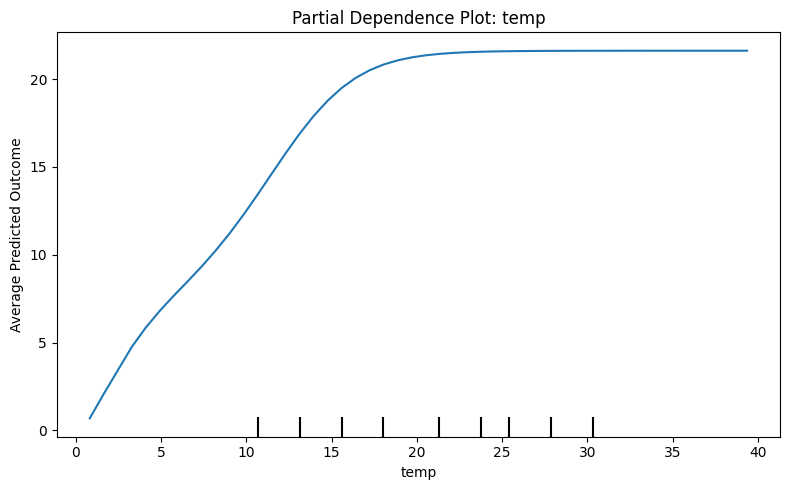

In [24]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

temp_index = X.columns.get_loc('temp')
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(model, X, [temp_index], ax=ax)
plt.title("Partial Dependence Plot: temp")
plt.xlabel("temp")
plt.ylabel("Average Predicted Outcome")
plt.tight_layout()
plt.show()

**ICE: Individual Conditional Expectation Plot**

The procedure is very similar to PDP but stops before the final averaging step:

1. Select a Feature and Instance: Choose a feature to analyze (e.g., Weight) and a specific data instance (e.g., Person A).
2. Replicate and Replace: Create a set of modified copies of Person A. In each copy, replace the value of Weight with a unique value found in the dataset (ranging from minimum to maximum), while keeping all other features (like Height) constant.
3. Predict: Feed these modified copies into the model to generate a prediction for each one.
4. Trace the Curve: Plot the resulting predictions against the Weight values. This creates a single line showing how the model behaves for Person A specifically.
5. Repeat: Repeat this process for multiple instances (e.g., Person B, Person C) to generate a collection of curves.

**ICE solves the averaging problem found in PDPs:** If the model predicts an increase in output for one group of people as a feature increases, but a decrease for another group, the PDP (which averages these effects) might show a flat line, falsely suggesting the feature has no impact. ICE plots show every individual curve, revealing these heterogeneous relationships.

In [25]:
# Select a few random instances from dataset
ice_samples = X.sample(n=50, random_state=42)
x_values = sorted(X[feature_name].unique())
# Compute curve for each sampled instance
ice_curves = []
for _, instance in ice_samples.iterrows():
  # Repeat the current instance for each x_value
  pred_data = pd.DataFrame([instance] * len(x_values))
  # Set feature column to range of x_values
  pred_data[feature_name] = x_values
  preds = model.predict(pred_data[model.feature_names_in_])
  ice_curves.append(preds)
ice_curves = np.array(ice_curves)

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

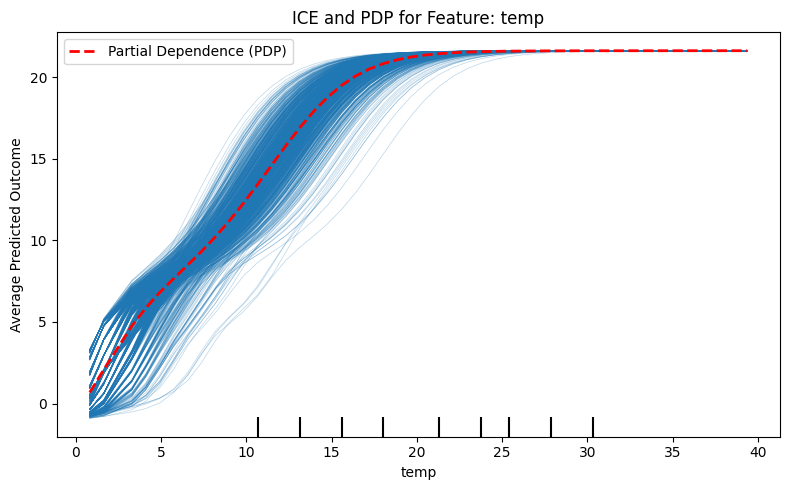

In [26]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

temp_index = X.columns.get_loc('temp')
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    model,
    X,
    [temp_index],
    kind='both',
    ax=ax,
    ice_lines_kw={'alpha': 0.3},
    pd_line_kw={'color': 'red', 'linewidth': 2, 'label': 'Partial Dependence (PDP)'}
)
plt.title("ICE and PDP for Feature: temp")
plt.xlabel("temp")
plt.ylabel("Average Predicted Outcome")
plt.tight_layout()
plt.show()

# Saliency Mapping

Saliency mapping (also known as heatmap or attribution mapping) identifies which parts of an input were most influential in a model's specific prediction.

## Occlusion and Adaptive Occlusion

Occlusion is a simple, **model-agnostic** method that identifies critical regions by "blacking out" portions of an input and measuring the change in the model's output (Adaptive Occlusion attempts to minimize the occluded area while maintaining the same prediction output w/o occlusion). It produces a saliency map where regions that cause the largest prediction swings are highlighted as important. Its main drawbacks include high computational costs and extreme sensitivity to hyperparameters like kernel size and the chosen baseline value (e.g., black vs. noise).

## GAP: Global Average Pooling

Global Average Pooling (GAP) is a dimensionality reduction technique that computes the average value across all spatial dimensions of a feature map, reducing a 3D tensor to a 1D vector. It replaces fully connected layers at the end of convolutional neural networks.

**Mathematical Definition:** For a feature map with shape $(C, H, W)$ where $C$ is the number of channels, $H$ is height, and $W$ is width:

$$z_c = \frac{1}{H \times W} \sum_{i=1}^{H} \sum_{j=1}^{W} f_c[i, j]$$

where $z_c$ is the output for channel $c$, and $f_c[i,j]$ is the value at position $(i,j)$ in channel $c$.

**Output shape:** $(C,)$ — a single scalar value per channel.

## CAM: Class Activation Mapping

$$
\text{CAM}_c(x, y) = \sum_k w_{c,k} * F_k(x, y)
$$

CAM is a **model-specific**: It requires a specific architecture (Global Average Pooling (GAP) followed by a linear layer). The convolutional feature maps are processed through Global Average Pooling (GAP) to create a linear model just before the final prediction. By multiplying these feature maps by their corresponding class weights and summing them (often using a ReLU), the model generates a heat map of the discriminant regions. While semantic quality improves in deeper layers, the resolution of these explanations tends to decrease as the maps get smaller.

:::{prf:example} CAM Calculation
$$
\begin{align}
ReLU(x) &= max(0, x) \\
w &= [2.0, -1.0, 0.5] \quad \text{weights} \\
f &= [0.5, 0.0, 2.0] \quad \text{feature map at pixel (i, j)} \\
\end{align}
$$

$\text{CAM} = \text{ReLU}\left((2.0 \times 0.5) + (-1.0 \times 0.0) + (0.5 \times 2.0)\right) = 2.0$
:::

![Class Activation Mapping](advanced-deep-learning/Class-Activation-Mapping.png)

## Grad-CAM

Is more flexible than standard CAM because it uses **gradients** to weigh the importance of feature maps rather than requiring a specific architecture (linear model at the end). Importance is assessed by "wiggling" individual feature maps and measuring the sensitivity of the output.

Frees up architecture constraints; Don’t have to compromise accuracy as final conv layer can go into any function, not just a SoftMax; Final feature map resolution dictates the graduality of the explanation; Tension between high level semantics and explanatory resolution; Cannot compare the intensity of final heatmaps between different instances; Still requires CNN.

## LIME: Local Interpretable Model-Agnostic Explanations

LIME  is a **model-agnostic** method that provides "local" explanations for individual instances, working across tabular, text, and image data. It operates by randomly sampling data around a specific prediction and weighting those samples using a proximity measure - typically an exponential kernel $\exp(-D(x,z)^2 / \sigma^2)$ - so that points closer to the original input are more important. A simple, interpretable **surrogate model** (such as a linear model) is then trained to mimic the black-box model's behavior in that local neighborhood.

:::{figure} advanced-deep-learning/LIME-Idea.jpg
Basic Idea of LIME
:::

Upper-left: Data with two features, x1 and x2. Classifier f labels class 1 blue and class 0 grey.  Steps of LIME

Upper-right: We want to explain the yellow data point. Generate new samples (black dots).

Lower-left: Weigh the dots such that dots closer to the yellow point are more important.

Lower-right: Train a surrogate white box model g to label the new data points such that it behaves like our black box model (locally)

:::{image} advanced-deep-learning/LIME-Generalized.png
:width: 100%
:align: center
**Left:** Blackbox-Model, **Right:** Surrogate Model, **Bottom:** Enforces locality for predictions: If the distance is large, it should be less relevant if the prediction is different.
:::

1. We want to explain the black box model f. Particularly it decision for the central orange point in the original unprimed data space. This point a sentence, row, or an image.
2. Transport the data point into a binary representation shown here as the dark blue central point in the primed data space.
3. Randomly sample data from the binary representation to generate a z’ dataset (other blue points).
4. Map the new sampled dataset back to the original image space such that we have an unprimed dataset z.
5. Train a white box model g on the primed dataset such that it has high fidelity, i.e., behaves the same as the black box model f when labelling the new dataset. Loss function can be seen at the bottom of the plot.
6. Use a proximity measure that places more weight on points similar to the original data point we want to explain (exponential kernel).

# Vanilla Gradients

Vanilla gradients method generates noisy saliency maps, often highlighting pixels that are not semantically important for a model's prediction. Conversely, the method can fail to highlight pixels that are crucial. Once a model is confident of its prediction, changing a few pixel values is likely to not change the models prediction. This is due to how contextually dependent (correlated) image data is. When a model learns how a value of a specific pixel affects the model’s prediction, the gradient for that pixel will become smaller and smaller until it is eventually zero. This is called saturation.  We therefore require a trick that allows us to access the gradient information of each pixel when the model is more sensitive to its change.

```python
def grad_x_input(model, input_tensor, target_cls):
  # Enable gradients for input tensor:
  input_tensor.requires_grad = True
  # Forward pass:
  model.zero_grad()
  output = model(input_tensor)
  # Create one-hot vector for target class:
  one_hot = torch.zeros_like(output)
  one_hot[0][target_cls] = 1
  # Backward pass:
  output.backward(gradient=one_hot)
  # Vannilla gradients from input:
  gradients = input_tensor.grad.data.cpu().numpy()[0]
  gradient_x_input = gradients *\
      input_tensor.detach().cpu().numpy()[0]
  return gradient_x_input
```

# Integrated Gradients

Similar to Vanilla Gradients, but don't do just one step - instead do linear interpolation between a baseline image to the target image, calculate the gradient at each step and sum them up (integrate them):

$$\phi_i^{IG}(f, x, x') = (x_i - x_i') \int_{\alpha=0}^{1} \frac{\delta f(x' + \alpha(x - x'))}{\delta x_i} d\alpha$$

where: $\phi_i^{IG}$ is the integrated gradient attribution for feature $i$, $f$ is the model function, $x$ is the input of interest, $x'$ is the baseline input, $\alpha$ is the interpolation parameter ranging from 0 to 1, $\frac{\delta f}{\delta x_i}$ is the partial derivative of $f$ with respect to input feature $i$

:::{prf:axiom} Completeness
Integrated gradients satisfies several desirable properties, including the completeness axiom:

$$\sum_{i} \phi_i^{IG}(f, x, x') = f(x) - f(x')$$

This holds for any baseline $x'$. Completeness is a desirable property because it states that the importance scores for each feature break down the output of the network: each importance score represents that feature's individual contribution to the network output, and added when together, we recover the output value itself. The completeness axiom also provides a way to measure convergence.
:::

**Challenges choosing a baseline:** Max distance: Fixes the issue with distance from baseline pre-factor but doesn’t represent missingness, has as much information as original image.

Blur: Intuitive since the image is missing information, however biased to highlight high frequency data, i.e. pixels close together and very different will result in an average that intern generates a larger prefactor an path length to integrate along.

Uniform (noise): Sample random image within the allowed pixel range assumes the pixels are uncorrelated - which is not true.

Gaussian (noise): Same problems as with uniform, but with more control.

# Local vs. Global Explanations

**Local:** Explains a specific instance (e.g., "Why was *this* loan denied?").

**Global:** Summarizes feature importance across the entire dataset.

# SHAP: Shapley Values

Based on game theory: how to fairly distribute the "payout" (prediction) among "players" (features)?

![Shapley-Values-Idea](advanced-deep-learning/Shapley-Values-Idea.png)

$$
\phi_i(x)
= \underbrace{\sum_{S \subseteq N \setminus \{i\}}}_{a} \quad
\underbrace{\frac{|S|! \times \left(|N| - |S| - 1\right)!}{|N|!}}_{b} \quad
\underbrace{\left( f_\theta(S \cup \{i\}) - f_\theta(S) \right)}_{c}
$$

for $|S|$ is the size of the subset, $|N|$ is the total number of features and $(|N| - |S| - 1)!$ the number of features not in S excluding $i$.

**a)** Probability of obtaining each subset $S$ when randomly selecting features **b)** Sum over all subsets of total $N$ features **c)** difference between model prediction with and without feature $i$

**Computational Complexity is Intractable:** $2^n$ for $n$ features

**Monte Carlo Approximation**

Approximate missingness by using random features from random samples as background. $x_{+j}$ is including feature and $x_{-j}$ is without the feature we are interested in. Normalization simpler because sample from a flat distribution, i.e., every combination is equally probable. To reduce the production of unrealistic data, we only use the background from a single instance of a time and don’t mix the z’s from different instances (i.e. keep the data distribution as similar as possible).

![Monte Carlo Approximation of Shapley Values](advanced-deep-learning/MC-Shapley-Values.png)

# Expected Gradients

:::{image} advanced-deep-learning/Expected-Gradients.png
:width: 100%
:align: center
:::

**Idea:** Sample an image from our dataset and use it as baseline. Calculate the integrated gradients. Rinse and repeat.

We don't want to see the effects of our baseline on the models output. All the other baselines biased the results (black, white, blur), even the gaussian noise assumes pixels are uncorrelated. By using the background dataset as a baseline, we ensure that we respect the dependencies between pixels. Additionally, integrating along many image paths against this background ensures that in the limit, the baseline leaves the output stationary with respect to the models average prediction, since some feature will fight to increase the models prediction, while others will try to decrease it. This implies that the additional integration over multiple image paths is an effective way to take pseudo subsets, i.e., **the additional integral allows us to effectively turn features on and off without introducing bias into our explanation.**

# Counterfactual Explanations

A counterfactual explanation of a prediction describes the **smallest change to the feature values that changes the prediction to a predefined output**.

Counterfactuals are human-friendly explanations because they are contrastive to the current instance and because they are selective, meaning they usually focus on a small number of feature changes.

**Characteristics we want from our counterfactuals:** Should reach the target output (probabilistically within a small region about it). Should be as similar as possible to the instance regarding feature values. Should also change as few features as possible. Should produce multiple diverse counterfactual explanations. Should have feature values that are likely.

**Counterfactuals (Wachter et al.)**

:::{image} advanced-deep-learning/Counterfactuals-Wachter-et-al.png
:width: 100%
:align: center
:::

**Strengths of Counterfactual Explanations:** Interpretation of counterfactual explanations is very clear (Think of LIME, here we are not sure how safe it is to interpolate our result). Counterfactuals do not require access to the data or the model (just require the models predictive function, allows companies to protect their trade secrets, models, and data while still offering explanations). Works with systems that do not use machine learning (Could be a set of handwritten rules / heuristics evolutionary algorithms also used in neuromorphic ML)

**Limitations of Counterfactual Explanations:**  Hyper local (Specific to one instance and one counterfactual, meaning not useful for extracting model and data insights).

# Generative AI

**Goal:** $p_{data} \sim p_{model}$, Model the data’s density distribution. If accurate, we can sample new points from the distribution and they will be properly correlated such that the new instance looks like it came from the data distribution.

**Explicit Density:** Models the probability $P(x)$ directly (PixelRNN, LLMs, Normalizing Flows, GMM, VAE, RBM (Restricted Boltzmann Machines)).

**Implicit Density:** Learns to sample from the distribution without explicitly calculating $P(x)$ (GANs, Diffusion).

**Discriminative Model:** Learns a probability distribution  $P(y \mid x)$.

**Generative Model:** Learns a probability distribution $P(x)$.

**Conditional Generative Model:** Learn a probability distribution $P(x \mid y)$.

:::{image} advanced-deep-learning/Key-Generative-Models.png
:width: 100%
:align: center
:::

![Generative Model Comparison](advanced-deep-learning/Generative-Model-Comparison.png)

**Cross Entropy** Commonly used as a loss function for classification tasks. Measures the additional number of bits of information necessary to determine a random variable when using an estimate $q$ of the true probability distribution $p$. Measure how uncertain we are about the models output value. Can only be as uncertain as the entropy of the labels. Always greater than zero.

$$
H(p, q) = -\sum_x p(x) \log q(x)
= H(p) + D_{\mathrm{KL}}(p \| q)
$$

**Latent Variables:** A latent variable is a hidden or unobservable variable that helps explain patterns in data we can observe. Think of it as an underlying factor that we can't measure directly, but that influences or generates the data we can actually see. Examples in Machine Learning: Cluster membership, Feature maps in CNNs (unobserved abstract features that explain the prediction / observation), Compressed representation of the input (latent space i.e. for Grad-CAM VAE), Low-dimensional embedding of high-dimensional data (t-SNE), underlying factors or components explaining observed variance (PCA).

::::{prf:definition} Expectation Maximizatiom Algorithm
An algorithm that helps latent variable models locate a local maximum for the likelihood function by iterating over a two step procedure:

:::{image} advanced-deep-learning/EM-Algorithm.png
:width: 100%
:align: center
:::

_E-step:_ Freeze parameters $\theta$ and make prior $q = posterior$. _M-step:_ Freeze $q$ and update parameters $\theta$ to maximize $p$.
::::

## VAE: Variational Auto-Encoder

The VAE is a **generative model** that extends the AE structure to estimate the probability density of the data. Instead of mapping an input to a fixed point in the latent space, it maps it to a probability distribution. Optimizes the Evidence Lower Bound (ELBO). The Encoder approximates the posterior $q(z|x)$, and the KL divergence forces it close to a Gaussian prior.

**VAEs require three main ideas:**

(1) Use of the evidence lower bound (ELBO) to approximate the likelihood function, leading to a close relationship to the EM algorithm.

(2.) Amortized inference in which a second model, the encoder network, is used to approximate the posterior distributions over latent variables in the E step, rather than evaluating the posterior distribution for each data point exactly

(3.) Making the training of the encoder model tractable using the reparameterization trick

**Latent Space:** The encoder outputs parameters for a distribution (Mean $\mu$ and Variance $\sigma$) rather than a single vector. The system then samples $z$ from this distribution to feed the decoder.

**Smoothness:** The latent space is continuous, allowing for valid interpolation between points (e.g., morphing one image into another), unlike standard AEs.

**Trade-off:** VAEs are easy to train and fast to sample from, but often produce blurrier images compared to GANs,.

**Training:** The VAE optimizes only the **Evidence Lower Bound (ELBO)** (because computing the KL diverging is intractable). Since we only approximate the true posterior distribution with an encoder, we will always be equal or less than the likelihood. _E-step:_ Fixed decoder, improve posterior approximation with encoder. _M-step:_ Fixed encoder, increase value of the ELBO by optimizing the decoder.

**Loss Function (ELBO):** The ELBO consists of two competing terms:

1. **Reconstruction Loss:** Ensures the output resembles the input (Likelihood).
2. **KL Divergence:** A regularization term that forces the learned latent distribution $q(z|x)$ to approximate a standard Gaussian prior $p(z)$ (typically $\mathcal{N}(0,1)$).

$$ \mathcal{L} = \mathbb{E}_{q}[\log p(x|z)] - D_{KL}(q(z|x) || p(z))$$

**Equation Insight:** If the encoder models a Gaussian distribution, the KL term has a simple analytic expression involving $\mu$ and $\sigma$:

$$D_{KL}(q(z|x) || p(z)) = \frac{1}{2} \sum_{j=1}^{M} \left( 1 + \ln(\sigma_j^2x) - \mu_j^2x - \sigma_j^2x \right)$$

**Inputs:** The encoder network directly outputs the mean ($\mu$) and variance ($\sigma^2$) for each latent dimension $j$.

**Result:** This formula penalizes the network if: $\mu$ diverges from **0** (the $-\mu^2$ term). $\sigma^2$ diverges from **1** (the $1 + \ln(\sigma^2) - \sigma^2$ terms).

This insight refers to a computational shortcut that makes training Variational Autoencoders (VAEs) efficient.

**Reparameterization Trick:**

_The Problem:_ In a standard VAE, the encoder outputs the parameters of a distribution (mean $\mu$ and variance $\sigma$). The network must then **sample** a latent vector $z$ from this distribution to feed the decoder. This sampling operation is stochastic (random). Standard backpropagation cannot compute gradients through a random node, meaning the encoder's weights cannot be updated to minimize the error.

_The Solution:_ The reparameterization trick solves this by expressing the random variable $z$ as a deterministic function of the model parameters and an independent source of noise. Instead of sampling $z$ directly from $\mathcal{N}(\mu, \sigma^2)$, the model:

(1.) Samples a noise vector $\epsilon$ from a fixed standard normal distribution: $\epsilon \sim \mathcal{N}(0, 1)$

(2.) Calculates $z$ using the deterministic formula: $z = \mu + \sigma \cdot \epsilon$

The randomness is now contained in $\epsilon$, which is treated as a constant input during backpropagation. The latent vector $z$ is now a differentiable function of $\mu$ and $\sigma$, allowing gradients to flow from the decoder back into the encoder.

## GAN: Generative Adversarial Network

**The MinMax Game:** A **Generator** creates fake images from noise, and a **Discriminator** tries to distinguish them from real data.

**Minmax Loss:**
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

:::{image} advanced-deep-learning/GAN.png
:width: 100%
:align: center
:::

**Training: Why $p_g \to p_{data}$?**

When $p_g(x) \gg p_{data}$: $D(x) \approx 1$, $x$ is classified as real

When $p_g(x) \approx p_{data}$: $D(x) \approx 0.5$, discriminator is uncertain as $D$ produces realistic images

When $p_g(x) \ll p_{data}$: $G(x) \approx 0$, the discriminator becomes uncertain because $D$ produces GAN objective

**Wasserstein GAN:** Solves GAN Instability (long convergence and mode collapse). Standard GAN loss minimizes JS-divergence leading to vanishing gradients when and have no overlap. Replaces JS divergence with the Wasserstein Distance (Earth Mover's Distance) which measures the cost of transforming one distribution into another. Use the Kantorovich-Rubinstein duality to arrive at the new minmax. Discriminator bound between [0,1] now replaced by a "Critic" f which outputs real values, so no sigmoid in final layer. Weights of the critic are clipped to a small range (e.g., [−0.01,0.01]) to ensure f's gradients are well behaved and the duality equation holds.

**CycleGAN:** Learns style transfer between two domains without paired data (e.g., horses to zebras) using a **Cycle Consistency Loss** ($F(G(x)) \approx x$) to allow style transfer without paired training data.

# SSL: Self-Supervised Learning

**Pretext Tasks:** The model solves "fake" tasks to learn a **backbone** representation. Examples: Predicting image rotation, solving jigsaw puzzles, or colorization. Success is measured by performance on **downstream tasks** (e.g., classification) using only a small amount of labeled data.

**SimCLR: Contrastive Learning**

_Method:_ Create two augmented versions of the same image (positive pair) and maximize their similarity while minimizing similarity with all other images in the batch (negative pairs).

_Order of Operations:_ Data Augmentation $\to$ Encoder $\to$ Projection Head $\to$ Contrastive Loss.

_Projection Head:_ A small MLP that "absorbs" the contrastive loss, allowing the encoder to maintain general features.

**BYOL: Bootstrap Your Own Latent**

Learns representations **without negative examples**.

Uses two asymmetric networks (**Online** and **Target**). The Target weights are an **Exponential Moving Average (EMA)** of the Online weights, preventing the model from collapsing to a trivial constant output and negative pairs.